# Credit Risk Notebook
Using the German Credit dataset, this notebook creates a machine learning model to categorise consumers as having good or bad credit risk. Because it demonstrated superior recall for high-risk clients—a crucial factor in financial decision-making—logistic regression was chosen.

1. Libraries import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

2. Loading Dataset

In [ ]:
cr = pd.read_csv("/content/sample_data/german_credit_data.csv")

3. Displaying first 5 rows and basic dataset infomation


In [ ]:
print("First 5 rows of dataset:")
print(cr.head())

print("\nDataset Info:")
print(cr.info())

print("\nMissing Values:")
print(cr.isnull().sum())

First 5 rows of dataset:
        status_account  month_duration  \
0               < 0 DM               6   
1        0 to < 200 DM              48   
2  no checking account              12   
3               < 0 DM              42   
4               < 0 DM              24   

                                      credit_history              purpose  \
0  critical account/ other credits existing (not ...     radio/television   
1           existing credits paid back duly till now     radio/television   
2  critical account/ other credits existing (not ...            education   
3           existing credits paid back duly till now  furniture/equipment   
4                    delay in paying off in the past            car (new)   

   credit_amount               status_savings years_employment  \
0           1169  unknown/ no savings account       >= 7 years   
1           5951                     < 100 DM   1 to < 4 years   
2           2096                     < 100 DM   4 to < 7 year

4. Dropping unnecessary index column if present

In [ ]:
cr = cr.drop(columns=["Unnamed: 0"], errors="ignore")

5. Define features and target. Handling missing values




In [ ]:
target_column = "target"

X = cr.drop(columns=[target_column])
y = cr[target_column]

X = X.fillna("Unknown")

6. Encodeing  categorical features and target variable


In [ ]:
label_encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

7. Split dataset into training and testing sets. Training model and making predictions.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

8. Evaluating model


Model Accuracy:
0.675

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.64      0.54        59
           1       0.82      0.69      0.75       141

    accuracy                           0.68       200
   macro avg       0.64      0.67      0.64       200
weighted avg       0.72      0.68      0.69       200


Confusion Matrix:


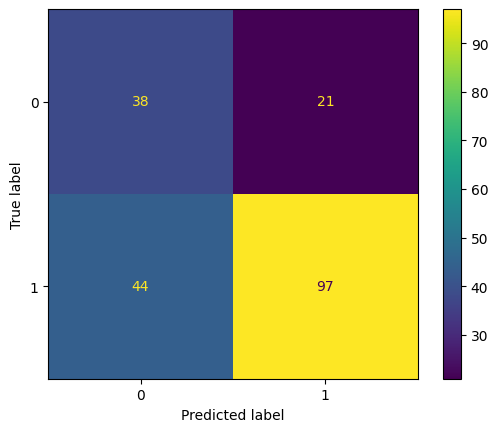

In [ ]:
print("\nModel Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cr_cm = confusion_matrix(y_test, y_pred)
disp_cr_cm = ConfusionMatrixDisplay(cr_cm)
disp_cr_cm.plot ()

9. saving trained modes

In [ ]:
with open("credit_risk_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("credit_label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open("credit_target_encoder.pkl", "wb") as f:
    pickle.dump(target_encoder, f)

with open("credit_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\nModel, encoders, and scaler saved successfully.")


Model, encoders, and scaler saved successfully.
